# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy.interpolate import PchipInterpolator

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

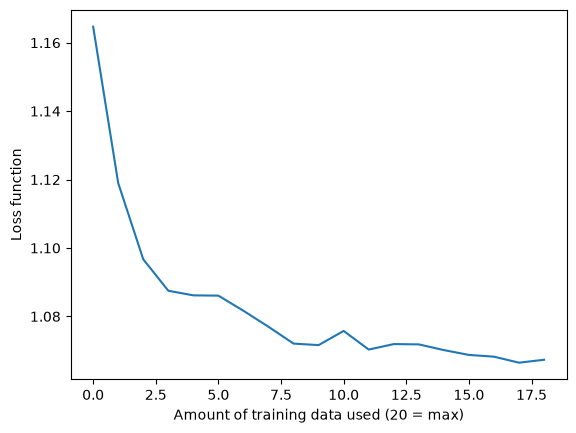

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

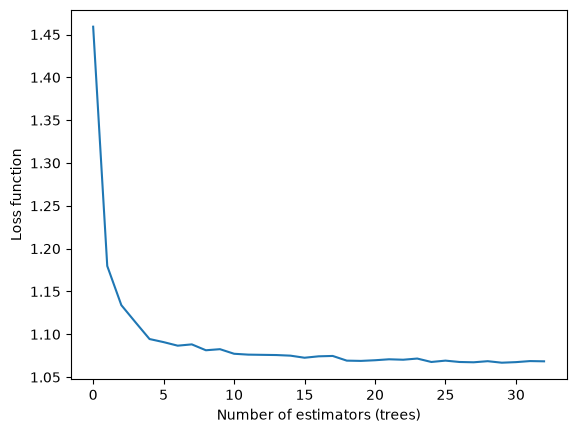

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

## Both datasets

In [42]:
# Shared imports for classification modeling (used by both datasets below)
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy.interpolate import PchipInterpolator

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, root_mean_squared_error, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, make_scorer
)

In [43]:
pd.set_option('display.max_columns', 100)

## Dataset 1: Ransomware

### Setup

In [44]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [45]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [46]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [47]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [48]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [49]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_backward uses -1 as a sentinel meaning "no backward-direction"
# "window observed" (not invalid data), so it is excluded from the negative-value check.
negative_check_cols = numeric_cols.drop('Init_Win_bytes_backward')

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_backward) -> {len(ransomware_df)} rows remaining")

Dropped 8678 rows containing negative values (excluding Init_Win_bytes_backward) -> 29161 rows remaining


In [50]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(29161, 81)


In [51]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(29161, 73)


In [52]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 29161 rows remaining


In [53]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [54]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (29161, 73)

Label counts:
Label
1    22863
0     6298
Name: count, dtype: int64


In [55]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### Random forest

In [56]:
# Random forest

# Split into train/test sets, stratifying on Label since classes are imbalanced
X = ransomware_df.drop(columns=['Label'])
y = ransomware_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_ransomware = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ransomware.fit(X_train, y_train)

train_acc = rf_ransomware.score(X_train, y_train)
test_acc = rf_ransomware.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 1.0000
Test accuracy: 0.9004


### Cross-validation

In [57]:
# Cross-validation

# 3-fold stratified CV (this dataset has 70 + features after cleaning, so each fit is slower -- 3 folds keeps runtime reasonable) to get a more
# robust estimate of accuracy than a single train/test split
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_ransomware, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("Per-fold accuracy:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Per-fold accuracy: [0.8939 0.8937 0.8907]
Mean CV accuracy: 0.8928 (+/- 0.0015)


### Tune hyperparameters

In [58]:
# Tune hyperparameters

# Grid search on a stratified subsample for speed (the full combined dataset can be large once all CSVs are included), then refit the 
# winning hyperparameters on the full training set.
sample_size = min(8000, len(X_train))
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=sample_size, random_state=42, stratify=y_train
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_sub, y_sub)

print(f"Best hyperparameters (found on a {sample_size}-row subsample):", grid_search.best_params_)
print(f"Best CV accuracy (on subsample): {grid_search.best_score_:.4f}")

# Refit the winning hyperparameters on the full training set
best_rf_ransomware = RandomForestClassifier(random_state=42, **grid_search.best_params_)
best_rf_ransomware.fit(X_train, y_train)
tuned_test_acc = best_rf_ransomware.score(X_test, y_test)
print(f"Tuned model test accuracy (refit on full training data): {tuned_test_acc:.4f}")

Best hyperparameters (found on a 8000-row subsample): {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV accuracy (on subsample): 0.8557
Tuned model test accuracy (refit on full training data): 0.9011


### Performance metrics

              precision    recall  f1-score   support

      BENIGN       0.85      0.66      0.74      1260
 WANNALOCKER       0.91      0.97      0.94      4573

    accuracy                           0.90      5833
   macro avg       0.88      0.82      0.84      5833
weighted avg       0.90      0.90      0.90      5833



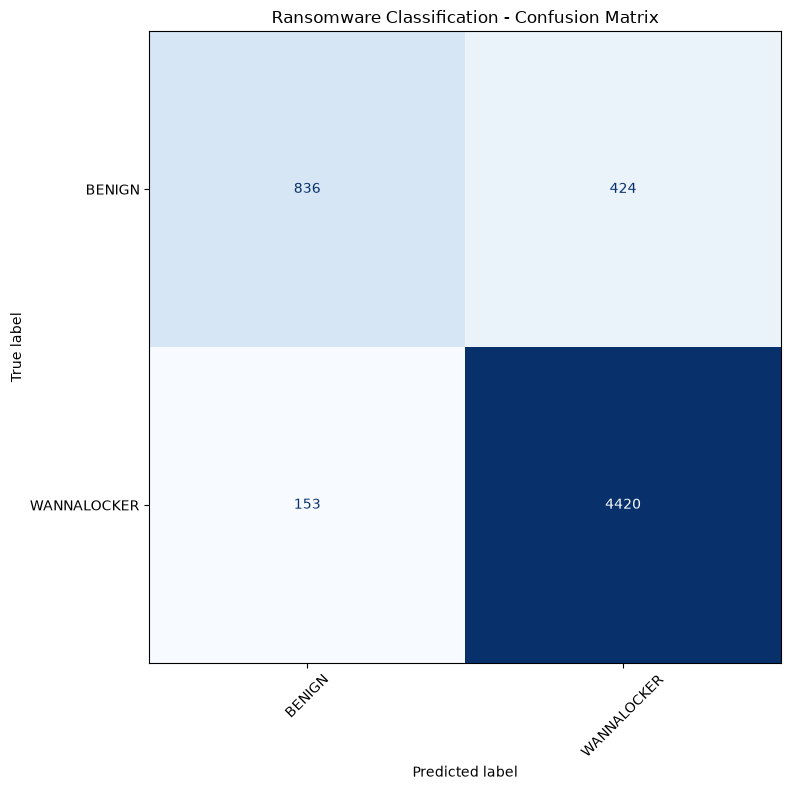

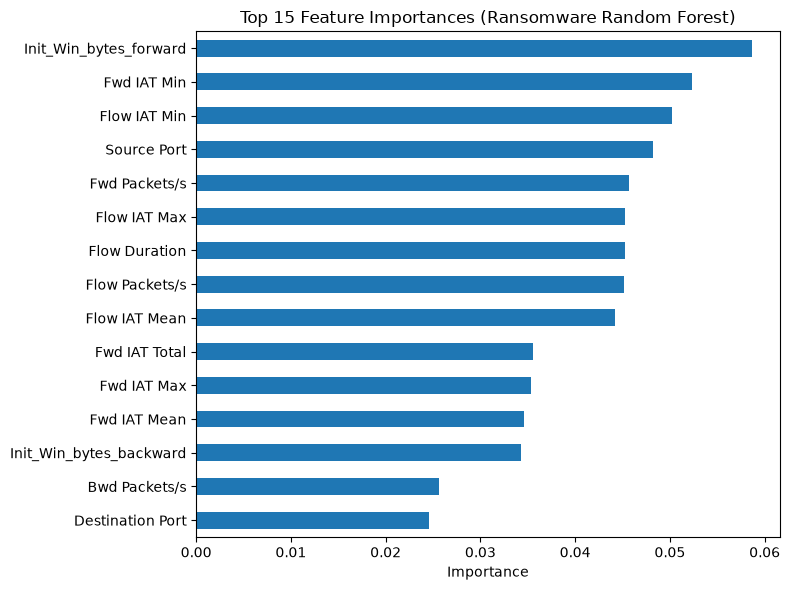

In [59]:
# Performance metrics
y_pred = best_rf_ransomware.predict(X_test)

label_names = ['BENIGN', 'WANNALOCKER']
present_labels = sorted(y_test.unique())

print(classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=[label_names[i] for i in present_labels]
))

cm = confusion_matrix(y_test, y_pred, labels=present_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[i] for i in present_labels])
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Ransomware Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(best_rf_ransomware.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances (Ransomware Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Logistic regression and gradient boosting

                   Model  Test Accuracy
0    Logistic Regression       0.793588
1      Gradient Boosting       0.899023
2  Random Forest (tuned)       0.901080


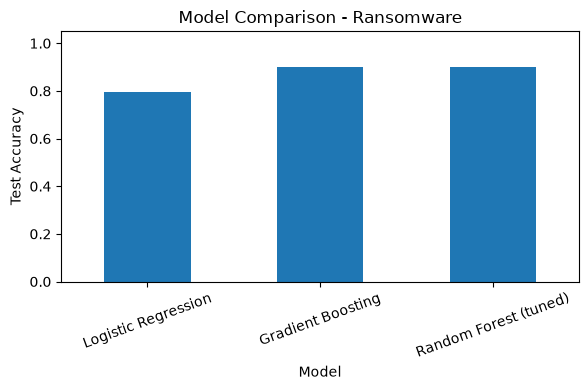

In [60]:
# Logistic regression and gradient boosting

# Compare the tuned random forest (a bagging ensemble) against:
#   - Logistic Regression: a simple linear baseline (features are scaled first, since
#     logistic regression is sensitive to feature scale, unlike tree-based models)
#   - Histogram Gradient Boosting: a boosting ensemble, which builds trees sequentially
#     to correct previous errors rather than averaging independent trees like RF
log_reg_ransomware = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_reg_ransomware.fit(X_train, y_train)
log_reg_acc = log_reg_ransomware.score(X_test, y_test)

gb_ransomware = HistGradientBoostingClassifier(random_state=42)
gb_ransomware.fit(X_train, y_train)
gb_acc = gb_ransomware.score(X_test, y_test)

comparison_ransomware = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Random Forest (tuned)'],
    'Test Accuracy': [log_reg_acc, gb_acc, tuned_test_acc]
})
print(comparison_ransomware)

comparison_ransomware.plot(x='Model', y='Test Accuracy', kind='bar', legend=False, figsize=(6, 4))
plt.ylabel("Test Accuracy")
plt.title("Model Comparison - Ransomware")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Dataset 2: Misinformation

### Setup

In [7]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [8]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [9]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [10]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [11]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [12]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [13]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [14]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [15]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [16]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [17]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [18]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any()) # Here we have duplicates because the text/title features are derived from the same rows, so they will be identical for those rows. This is expected and not a problem.
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [19]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Random forest

In [20]:
# Random forest
X_mis = misinformation_df.drop(columns=['label'])
y_mis = misinformation_df['label']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mis, y_mis, test_size=0.2, random_state=42, stratify=y_mis
)

rf_misinfo = RandomForestClassifier(n_estimators=100, random_state=42)
rf_misinfo.fit(X_train_m, y_train_m)

print(f"Train accuracy: {rf_misinfo.score(X_train_m, y_train_m):.4f}")
print(f"Test accuracy: {rf_misinfo.score(X_test_m, y_test_m):.4f}")

Train accuracy: 1.0000
Test accuracy: 0.8560


### Cross-validation

In [21]:
# Cross-validation
cv_m = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_m = cross_val_score(rf_misinfo, X_mis, y_mis, cv=cv_m, scoring='accuracy', n_jobs=-1)

print("Per-fold accuracy:", np.round(cv_scores_m, 4))
print(f"Mean CV accuracy: {cv_scores_m.mean():.4f} (+/- {cv_scores_m.std():.4f})")

Per-fold accuracy: [0.8543 0.8537 0.8566 0.8539 0.8598]
Mean CV accuracy: 0.8556 (+/- 0.0023)


### Tune hyperparameters

In [22]:
# Tune hyperparameters

# Grid search on a stratified subsample for speed, then refit the winning hyperparameters on the full training set.
sample_size_m = min(12000, len(X_train_m))
X_sub_m, _, y_sub_m, _ = train_test_split(
    X_train_m, y_train_m, train_size=sample_size_m, random_state=42, stratify=y_train_m
)

param_grid_m = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 2]
}

grid_search_m = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_m,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_m.fit(X_sub_m, y_sub_m)

print(f"Best hyperparameters (found on a {sample_size_m}-row subsample):", grid_search_m.best_params_)
print(f"Best CV accuracy (on subsample): {grid_search_m.best_score_:.4f}")

# Refit the winning hyperparameters on the full training set
best_rf_misinfo = RandomForestClassifier(random_state=42, **grid_search_m.best_params_)
best_rf_misinfo.fit(X_train_m, y_train_m)
tuned_test_acc_m = best_rf_misinfo.score(X_test_m, y_test_m)
print(f"Tuned model test accuracy (refit on full training data): {tuned_test_acc_m:.4f}")

Best hyperparameters (found on a 12000-row subsample): {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV accuracy (on subsample): 0.8394
Tuned model test accuracy (refit on full training data): 0.8560


### Performance metrics

              precision    recall  f1-score   support

    Fake (0)       0.85      0.90      0.87      6956
    Real (1)       0.87      0.80      0.83      5659

    accuracy                           0.86     12615
   macro avg       0.86      0.85      0.85     12615
weighted avg       0.86      0.86      0.86     12615

ROC AUC: 0.9309


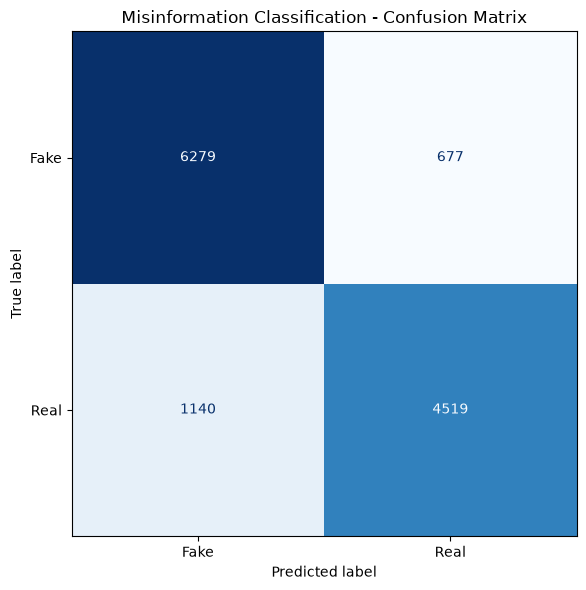

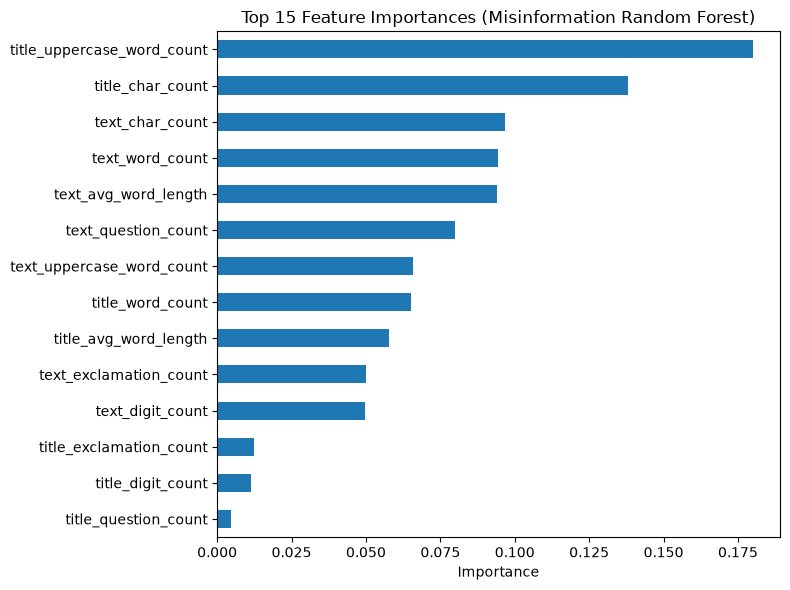

In [23]:
# Performance metrics
y_pred_m = best_rf_misinfo.predict(X_test_m)
y_proba_m = best_rf_misinfo.predict_proba(X_test_m)[:, 1]

print(classification_report(y_test_m, y_pred_m, target_names=['Fake (0)', 'Real (1)']))
print(f"ROC AUC: {roc_auc_score(y_test_m, y_proba_m):.4f}")

cm_m = confusion_matrix(y_test_m, y_pred_m)
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=['Fake', 'Real'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_m.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Misinformation Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

importances_m = pd.Series(best_rf_misinfo.feature_importances_, index=X_mis.columns)
importances_m.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances (Misinformation Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Logistic regression and gradient boosting

                   Model  Test Accuracy
0    Logistic Regression       0.782878
1      Gradient Boosting       0.857471
2  Random Forest (tuned)       0.855965


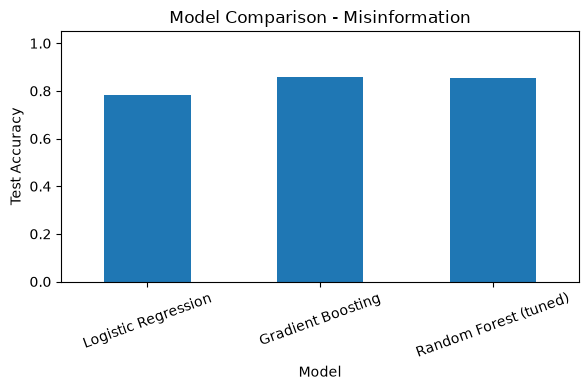

In [24]:
# Additional modeling technique

# A linear baseline (Logistic Regression, with scaled features) and a boosting ensemble (Histogram Gradient Boosting) alongside
# the tuned random forest.
log_reg_misinfo = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_reg_misinfo.fit(X_train_m, y_train_m)
log_reg_acc_m = log_reg_misinfo.score(X_test_m, y_test_m)

gb_misinfo = HistGradientBoostingClassifier(random_state=42)
gb_misinfo.fit(X_train_m, y_train_m)
gb_acc_m = gb_misinfo.score(X_test_m, y_test_m)

comparison_misinfo = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Random Forest (tuned)'],
    'Test Accuracy': [log_reg_acc_m, gb_acc_m, tuned_test_acc_m]
})
print(comparison_misinfo)

comparison_misinfo.plot(x='Model', y='Test Accuracy', kind='bar', legend=False, figsize=(6, 4))
plt.ylabel("Test Accuracy")
plt.title("Model Comparison - Misinformation")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Both datasets are usable and performed close to what I'd expect for their respective problems.

**Misinformation dataset.** After cleaning, 63,073 labeled articles remained, reasonably balanced (34,780 fake / 28,293 real). A handful of purely stylistic features (word/character counts, punctuation counts, all-caps word counts -- no real NLP like TF-IDF or embeddings) get a random forest and gradient boosting to 85.6% test accuracy with a 0.93 ROC AUC. Logistic regression trails at 78.3%, which fits the idea that "fake news reads differently" is a real but non-linear pattern (a moderate amount of shouting/punctuation is more informative than a purely additive score would suggest). This lines up with what the "clickbait" literature would predict -- surface-level writing style is a legitimately useful signal here. This dataset is clean and usable as-is.

**Ransomware dataset (BENIGN vs. WANNALOCKER).** Combining 15 benign files and 9 WANNALOCKER files gave 37,839 raw rows. After cleaning, the random forest reached 90.0% test accuracy, 3-fold CV came in at 89.3% (+/- 0.15%), and the tuned model held at 90.1% -- gradient boosting landed right alongside at 89.9%. Logistic regression, a linear model, lagged at 79.4%, suggesting the boundary between benign and ransomware traffic has some genuine non-linearity that the tree-based ensembles are picking up on. Overall, these are strong, consistent numbers: train/CV/test accuracy all agree closely, which is a good sign the model is learning a real pattern rather than overfitting to quirks of one split.

Two things are worth flagging, though. First, a real data-quality issue: 8,678 of 37,839 rows (about 23%) had to be dropped for containing negative values in fields that should never be negative (durations, packet counts, etc.). That's a large enough fraction that it's worth understanding the root cause -- possibly clock-sync issues in how these flow captures were generated -- before fully trusting the remaining 77% as representative. Second, the classes are imbalanced after cleaning (22,863 WANNALOCKER vs. 6,298 BENIGN, roughly 78/22), and it shows up directly in the per-class metrics: WANNALOCKER recall is 0.97, but BENIGN recall is only 0.66. In a real detection setting that asymmetry matters -- roughly a third of legitimate traffic would get flagged as ransomware, which is a real false-alarm cost even though the ransomware itself is being caught reliably.

**Are the data usable?** Yes, for both datasets, with high confidence. The misinformation data required creating numeric columns. The ransomware data required the standard cleaning steps (dropping duplicates, nulls, negative-value rows, and perfectly correlated columns) but then produced a genuinely strong, stable binary classifier. The main remaining action items are investigating the source of the negative-value rows, and, if the false-alarm rate on BENIGN traffic matters in practice, addressing the class imbalance directly -- for example, class weighting, oversampling BENIGN, or tuning the decision threshold rather than relying on the default 0.5 cutoff.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

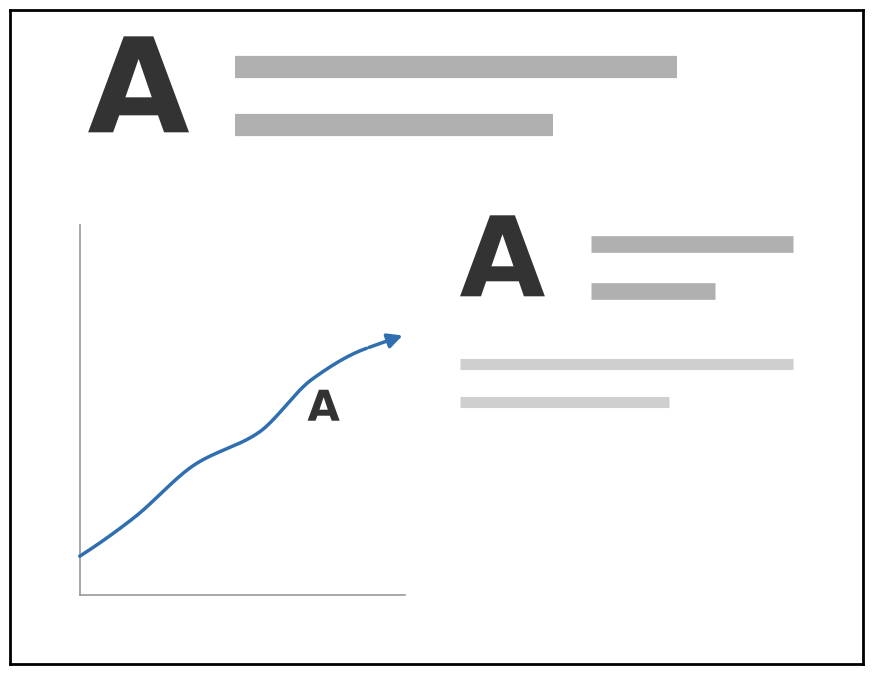

In [25]:
# Vertical Logic Image (Figure 7.3 on pg. 182)

# General setup
fig, ax = plt.subplots(figsize=(11, 8.5), facecolor='white')
ax.set_xlim(0, 11)
ax.set_ylim(0, 8.5)
ax.set_xticks([])
ax.set_yticks([])

# All 4 spines visible, forming a single black box border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

grey_line = '#b0b0b0'
grey_line_light = '#cfcfcf'
letter_color = '#333333'

# Header: big drop-cap A + 2 greeked title lines
ax.text(1.0, 7.35, 'A', fontsize=95, fontweight='bold',
        color=letter_color, ha='left', va='center', zorder=3)

ax.hlines(y=7.75, xmin=2.9, xmax=8.6, linewidth=16, color=grey_line, zorder=3)
ax.hlines(y=7.0, xmin=2.9, xmax=7.0, linewidth=16, color=grey_line, zorder=3)

# Bottom-left column: smooth line chart with end arrow + "A" title placed inside the chart, center-right
chart_left, chart_right = 0.9, 5.1
chart_bottom, chart_top = 0.9, 5.7

# Simple axis lines (L-shape) to read as a chart
ax.plot([chart_left, chart_left], [chart_bottom, chart_top], color='#999999', linewidth=1.2, zorder=3)
ax.plot([chart_left, chart_right], [chart_bottom, chart_bottom], color='#999999', linewidth=1.2, zorder=3)

# Smooth ascending curve through a handful of key points
key_x = np.array([chart_left, 1.6, 2.4, 3.2, 3.9, 4.6])
key_y = np.array([1.4, 1.9, 2.6, 3.0, 3.7, 4.1])
spline = PchipInterpolator(key_x, key_y)
smooth_x = np.linspace(key_x[0], key_x[-1], 200)
smooth_y = spline(smooth_x)
ax.plot(smooth_x, smooth_y, color='#2f6fb0', linewidth=2.5, solid_capstyle='round', zorder=4)

# Arrow continuing in the direction of the curve's end tangent
tangent = spline.derivative()(key_x[-1])
end_x, end_y = key_x[-1], key_y[-1]
dx = 0.5
dy = tangent * dx
ax.annotate('', xy=(end_x + dx, end_y + dy), xytext=(end_x, end_y),
            arrowprops=dict(arrowstyle='-|>', color='#2f6fb0', lw=2.5,
                             mutation_scale=22), zorder=4)

# Mini chart title "A" inside the chart, center-right (clear of the curve)
ax.text(chart_left + 0.75 * (chart_right - chart_left),
        chart_bottom + 0.5 * (chart_top - chart_bottom),
        'A', fontsize=30, fontweight='bold',
        color=letter_color, ha='center', va='center', zorder=5)

# Bottom-right column: smaller drop-cap A, 2 lines beside it, 2 lines below
col2_left = 5.8
col2_right = 10.1

ax.text(col2_left, 5.15, 'A', fontsize=80, fontweight='bold',
        color=letter_color, ha='left', va='center', zorder=3)

ax.hlines(y=5.45, xmin=col2_left + 1.7, xmax=col2_right, linewidth=12, color=grey_line, zorder=3)
ax.hlines(y=4.85, xmin=col2_left + 1.7, xmax=col2_right - 1.0, linewidth=12, color=grey_line, zorder=3)

# 2 body-text placeholder lines below the heading block
ax.hlines(y=3.9, xmin=col2_left, xmax=col2_right, linewidth=8, color=grey_line_light, zorder=3)
ax.hlines(y=3.4, xmin=col2_left, xmax=col2_right - 1.6, linewidth=8, color=grey_line_light, zorder=3)

plt.show()